## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 7. Востановление пропусков и прогноз значений временного ряда.**


#### **7.1 Аналитечкие методы востановления временного ряда**

##### *Краткое описание*

В данном пункте практической работы вам предстоит познакомиться с базовыми, аналитическими методами восстановления временных рядов.
Для выполнения данного пункта из каждой группы методов, представленных в ***табл. 7.1*** вам необходимо выбрать по одному методу восстановления ряда. При работе с первой группой, вам необходимо самостоятельно реализовать выбранный метод.  

**Табл. 7.1** - Группы аналитических методов восстановления.
№|Название группы|Модели и методы|
--|----|----|
1|Заполнение существующими значениями ряда|Средним, медианной, Hot-Deck|
2|Заполнение на основе близки значений|[Интерполяция](https://scikit-learn.org/stable/auto_examples/linear_model/plot_polynomial_interpolation.html),  [KNNi](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html)|
3|На основе матричных разложений|[CD-Rec](#Fixme:Дат ссылку), [SVD](https://pypi.org/project/fancyimpute/)|

##### 7.1.1 Загрузка и подготовка данных

In [1]:
# Клонируем свой форк репозитория с GitHub
!git clone https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse.git

Cloning into '2025-Selyutin-TimeSeriesCourse'...
remote: Enumerating objects: 312, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 312 (delta 19), reused 3 (delta 3), pack-reused 234 (from 2)
Receiving objects: 100% (312/312), 242.90 MiB | 13.16 MiB/s, done.
Resolving deltas: 100% (34/34), done.
Updating files: 100% (198/198), done.


In [2]:
%cd 2025-Selyutin-TimeSeriesCourse/practice/"07 Imputation and Forecast"

/content/2025-Selyutin-TimeSeriesCourse/practice/07 Imputation and Forecast


In [3]:
!ls

'07 Imputation and Forecast.ipynb'   datasets   modules


In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [16]:
path_data = "datasets/madrid.txt"
madrid = np.loadtxt(path_data)[:,0]
print(madrid.shape)

(25000,)


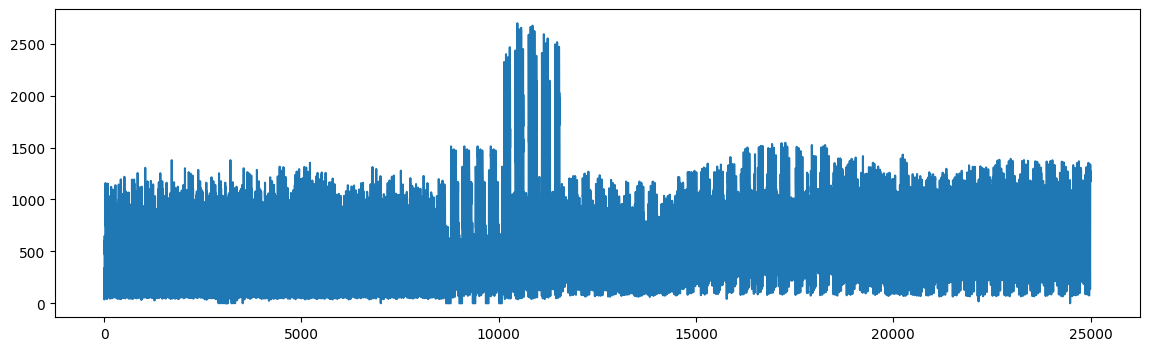

In [17]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(madrid[:])
plt.show()

Самостоятельно реализуйте функцию, принимающую на вход многомерный временной ряд и возвращающий:
1. Все подпоследовательности временного ряда, в которых некоторые значения временного ряда были заменены nan значениями.
2. Индексы пропущенных значений
   
Процент пропущенных значений должен регулироваться отдельным параметром.


In [18]:
def add_nan(x, percent=0.25, seed=None):
    if seed is not None:
        np.random.seed(seed)

    x_copy = x.copy().astype(float)
    N = len(x_copy)

    n_nan = int(N * percent)
    index = np.random.choice(N, n_nan, replace=False)

    x_copy[index] = np.nan
    return x_copy, index


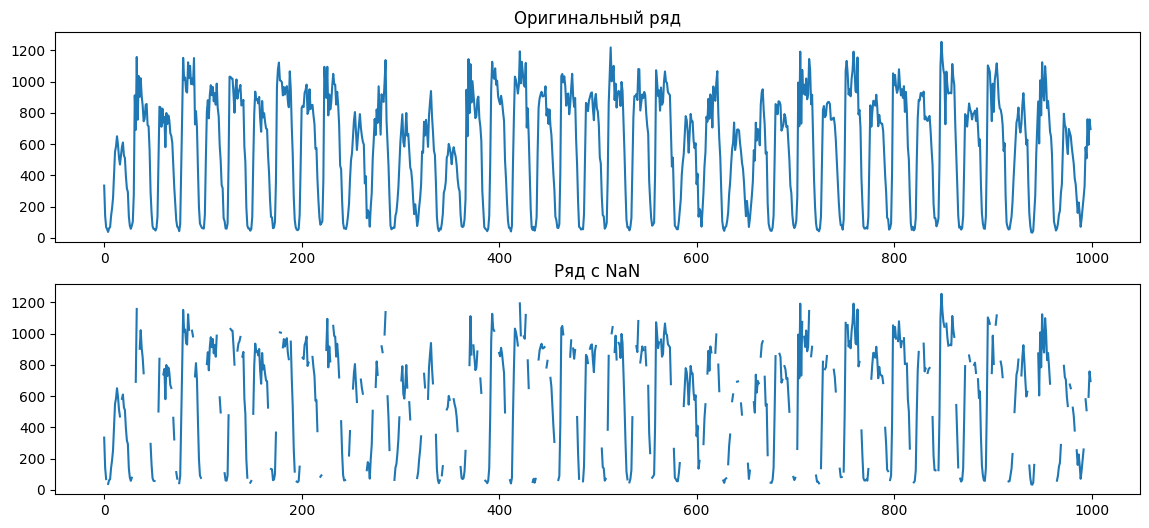

Индексы NaN: [12448  5038  4936  4256 16031 17032  6789 16611 23226  9295]


In [19]:
# Добавляем NaN
madrid_with_nan, index = add_nan(madrid, percent=0.25, seed=42)

# Визуализация
fig, ax = plt.subplots(figsize=(14,6), nrows=2, ncols=1)
ax[0].plot(madrid[:1000])
ax[0].set_title("Оригинальный ряд")
ax[1].plot(madrid_with_nan[:1000])
ax[1].set_title("Ряд с NaN")
plt.show()

print("Индексы NaN:", nan_indices[:10])

In [20]:
recovery = {}

##### 7.1.2 Заполнение существующими значениями ряда


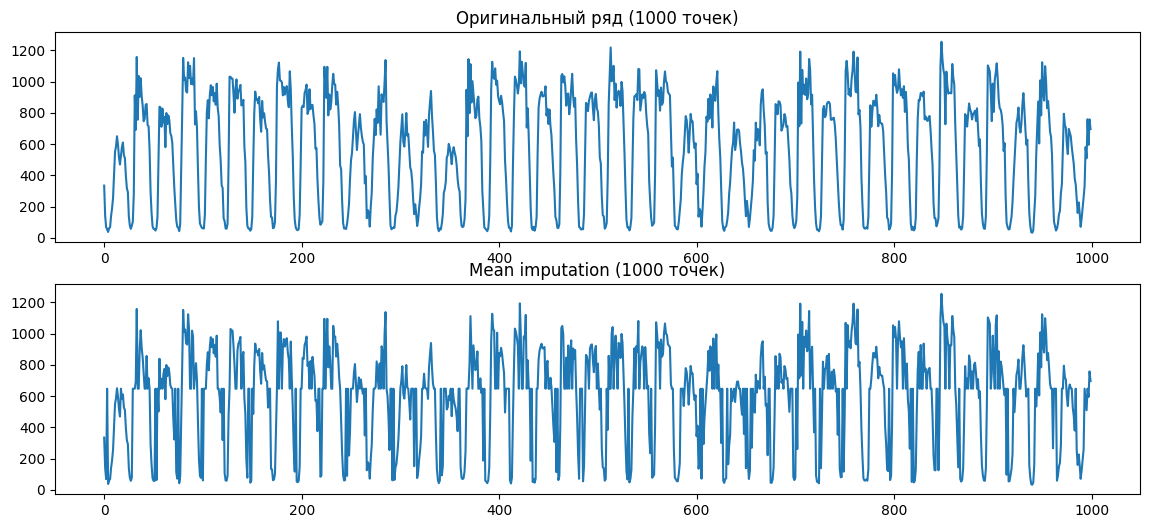

In [21]:
# 1) Mean imputation (заполнение средним)

madrid_mean = madrid_with_nan.copy()
madrid_mean[index] = np.nanmean(madrid_mean)
recovery["mean"] = madrid_mean


fig, ax = plt.subplots(figsize=(14,6), nrows=2)
ax[0].plot(madrid[:1000])
ax[0].set_title("Оригинальный ряд (1000 точек)")
ax[1].plot(madrid_mean[:1000])
ax[1].set_title("Mean imputation (1000 точек)")
plt.show()

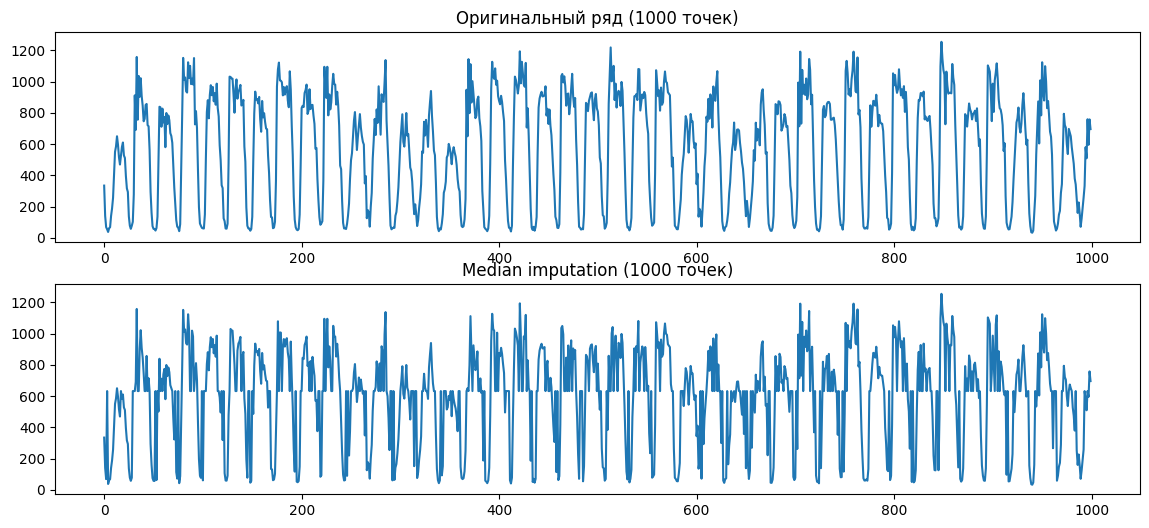

In [22]:
# 2) Median imputation (заполнение медианой)

madrid_median = madrid_with_nan.copy()
madrid_median[index] = np.nanmedian(madrid_median)
recovery["median"] = madrid_median

fig, ax = plt.subplots(figsize=(14,6), nrows=2)
ax[0].plot(madrid[:1000])
ax[0].set_title("Оригинальный ряд (1000 точек)")
ax[1].plot(madrid_median[:1000])
ax[1].set_title("Median imputation (1000 точек)")
plt.show()

Mean (среднее значение)  
Среднее значение вычисляется как сумма всех наблюдений, делённая на их количество.  
Плюсы:  
Хорошо работает при данных, близких к нормальному распределению.  
Иногда снижает шум, если ряд однородный.  
Минусы:  
Очень чувствителен к выбросам. Одно экстремальное значение значительно сдвигает среднее.  
Тянет восстановленные точки к одному общему центру распределения.  
Может искажать сезонность, амплитуду колебаний и тренды во временном ряду.  
Median (медиана)  
Медиана - это значение, которое находится в середине отсортированного ряда.  
Плюсы:  
Устойчива к выбросам и шуму.  
учше сохраняет реальную структуру распределения.  
Обычно даёт более корректные приближения пропущенных значений в нелинейных или асимметричных данных.  
Минусы:  
Может немного сглаживать динамику.  
В некоторых стационарных рядах даёт результат, похожий на mean, но не всегда лучше.  

Самостоятельно реализуйте один метод из первой группы ***табл. 7.1*** и проведите постановление данных, сохранив результаты восстановления.

##### 7.1.3 Заполнение на основе близких значений


Используя документацию одного из методов восстановления второй группы ***табл. 7.1*** и проведите восстановление данных, сохранив результаты восстановления.

In [23]:
from sklearn.impute import KNNImputer

In [24]:
def rolling_window(a, window, intersection=False):
    """
    Разбивает одномерный ряд на окна фиксированной длины.
    Если intersection=True - окна перекрываются.
    Если False - просто режутся подряд.
    """
    returns = []

    if intersection:
        # скользящее окно с шагом 1
        for i in range(0, a.shape[0] - window + 1):
            returns.append(a[i:i + window])
    else:
        # окна без перекрытия
        for i in range(0, a.shape[0], window):
            slice_ = a[i:i + window]
            # если последний кусок короче окна - можно отбросить или дополнить
            if len(slice_) == window:
                returns.append(slice_)

    return np.stack(returns)


In [25]:
madrid_slice = rolling_window(madrid_with_nan, 100, intersection=False)

print("Shape windows:", madrid_slice.shape)

Shape windows: (250, 100)


In [26]:
# KNN Imputer
imputer = KNNImputer(n_neighbors=5, weights="distance")

# Импьютер работает по строкам, поэтому оставляем форму (num_windows, window)
madrid_imputed_windows = imputer.fit_transform(madrid_slice)


# Собираем в единый ряд
madrid_knn = madrid_imputed_windows.reshape(-1)

madrid_knn = madrid_knn[:len(madrid)]

recovery["knn"] = madrid_knn

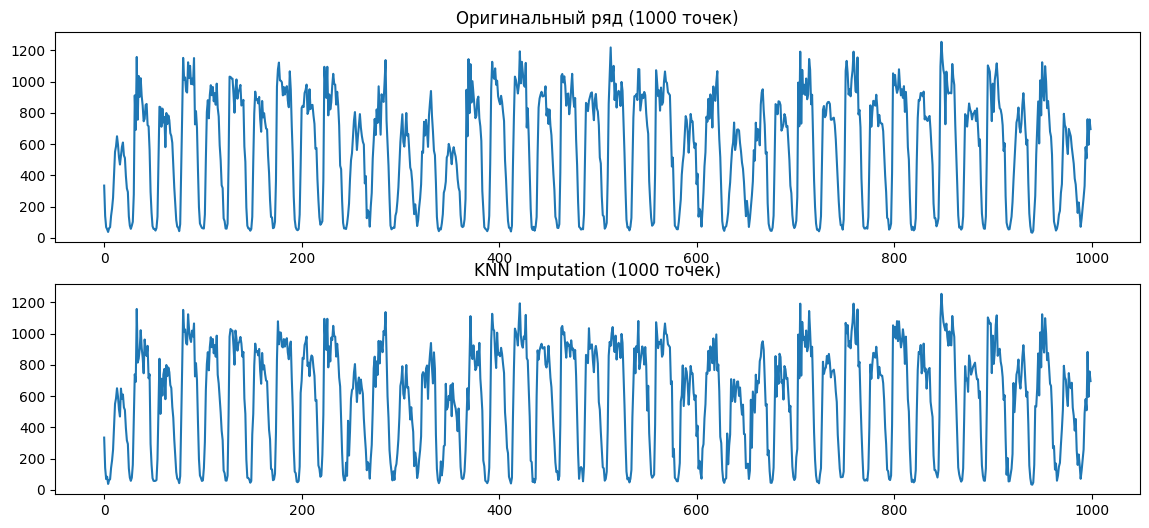

In [27]:

fig, ax = plt.subplots(figsize=(14,6), nrows=2)
ax[0].plot(madrid[:1000])
ax[0].set_title("Оригинальный ряд (1000 точек)")

ax[1].plot(madrid_knn[:1000])
ax[1].set_title("KNN Imputation (1000 точек)")
plt.show()

Для каждого элемента ищет k ближайших соседей по схожести окна, и восстанавливает NaN как взвешенное среднее.

Это более "умный" метод, чем mean/median, потому что учитывает локальную структуру данных.

##### 7.1.4 Заполнение на матричных преобразований

Используя документацию одного из методов восстановления третей группы ***табл. 7.1*** и проведите восстановление данных, сохранив результаты восстановления.

In [28]:
!pip install fancyimpute

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.0 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29879 sha256=941409f3f2ef15662395cc6e7132f3b7082309a20abe0390d206f2d94887a52c
  Stored in directory: /root/.cache/pip/wheels/df/20/91/e4850b9a31cf660c1bc95515d3bcbc8010e869e5de6d5baf07
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11331 sha256=cc2f52fc09c51ec95d612c2de9ea30455817b6d699662aecfa2a0d5bd0e6a8e8
  Stored in directory: /root/.cache/pip/wheels/89/11/61/aa5a3167bfff49218cd043a73a83034b9eadd858b0059521be
Successfully built fancyimpute knnimpute


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from fancyimpute import IterativeSVD
from sklearn.metrics import mean_squared_error

In [30]:
# Функция формирования окон
def rolling_window(a, window, intersection=False):
    returns = []

    if intersection:
        # sliding window with overlap
        for i in range(0, a.shape[0] - window + 1):
            returns.append(a[i:i+window])
    else:
        # non-overlapping windows
        for i in range(0, a.shape[0], window):
            slice_ = a[i:i+window]
            if len(slice_) == window:
                returns.append(slice_)
    return np.stack(returns)

In [31]:
#  Разрезаем ряд на окна
window_size = 100
madrid_slice = rolling_window(madrid_with_nan, window_size, intersection=False)

print("Matrix shape for SVD:", madrid_slice.shape)


# SVD-восстановление -
svd_imputer = IterativeSVD(rank=10,  # ранг низкоранговой аппроксимации
                           convergence_threshold=1e-5,
                           max_iters=100)

madrid_svd_windows = svd_imputer.fit_transform(madrid_slice)


# Склейка окон обратно в ряд
madrid_svd = madrid_svd_windows.reshape(-1)
madrid_svd = madrid_svd[:len(madrid)]  # обрезаем до длины исходного ряда

# Сохраняем
recovery["svd"] = madrid_svd

Matrix shape for SVD: (250, 100)
[IterativeSVD] Iter 1: observed MAE=345.386750
[IterativeSVD] Iter 2: observed MAE=267.723115
[IterativeSVD] Iter 3: observed MAE=189.297128
[IterativeSVD] Iter 4: observed MAE=117.093185
[IterativeSVD] Iter 5: observed MAE=101.826030
[IterativeSVD] Iter 6: observed MAE=100.264422
[IterativeSVD] Iter 7: observed MAE=100.026189
[IterativeSVD] Iter 8: observed MAE=100.005038
[IterativeSVD] Iter 9: observed MAE=100.024457
[IterativeSVD] Iter 10: observed MAE=100.048752
[IterativeSVD] Iter 11: observed MAE=100.070043


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


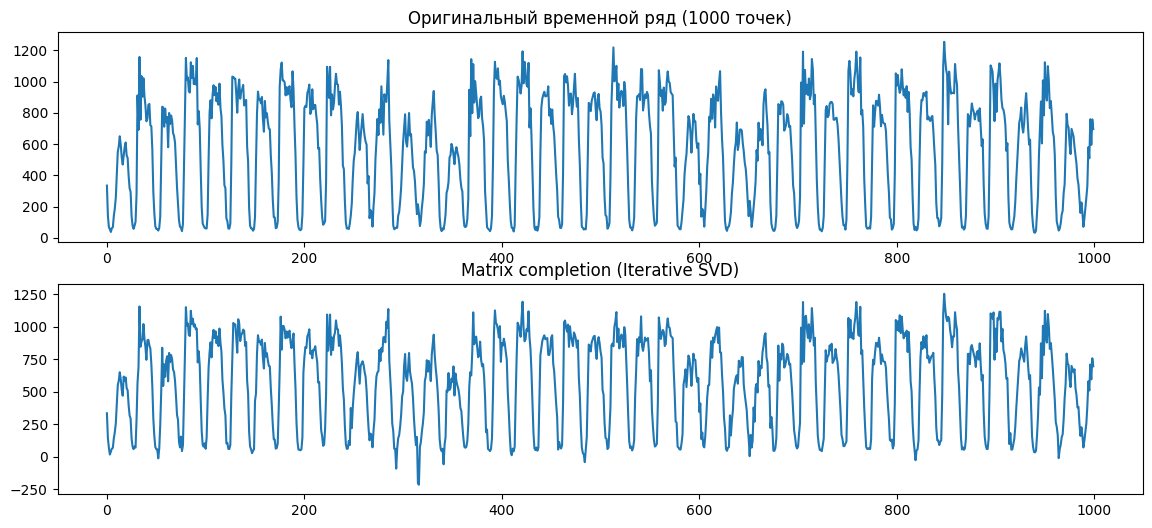

In [32]:
fig, ax = plt.subplots(figsize=(14,6), nrows=2)
ax[0].plot(madrid[:1000])
ax[0].set_title("Оригинальный временной ряд (1000 точек)")

ax[1].plot(madrid_svd[:1000])
ax[1].set_title("Matrix completion (Iterative SVD)")
plt.show()

1. Разделение ряда на окна

Ряд делится на небольшие последовательности фиксированной длины (например, 100 точек).

Каждое окно становится строкой матрицы.

Если ряд x имеет N точек, а окно длиной w, получается матрица размера (num_windows, w).

2. Формирование матрицы

Каждая строка = подпоследовательность ряда.

Пропущенные значения остаются NaN.

Матрица отражает структуру данных и взаимосвязь между соседними точками.

3. Инициализация пропусков

На первом шаге NaN заменяются начальными значениями (например, нулями или средним по строке).


4. Итеративное SVD-разложение

Выполняется разложение матрицы на низкоранговые компоненты

5. Повторение итераций

Процесс обновления NaN повторяется до сходимости:

ошибка на известных значениях стабилизируется,

изменения в пропущенных значениях минимальны.

6. Сборка восстановленного ряда

Восстановленные окна объединяются обратно в одномерный временной ряд.

Пропущенные значения заменяются на оценки, полученные с помощью Iterative SVD.

##### 7.1.5 Сравнение результатов восстановления.

Для каждой группы методов постройте методов основные метрики оценки качества постановления.
На основе метрик отберите лучшие методы постановления метрик и выберите лучшую группу методов.
Для лучших методов из каждой группы постройте графики сравнения реальных и восстановленных данных. Объясните результаты и сделайте вывод.



In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Функция для MAPE
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Собираем метрики
metrics = []

for name, restored in recovery.items():
    true_vals = madrid[index]
    pred_vals = restored[index]

    mae = mean_absolute_error(true_vals, pred_vals)
    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    mape_val = mape(true_vals, pred_vals)

    metrics.append([name, mae, rmse, mape_val])

df_metrics = pd.DataFrame(metrics, columns=["method", "MAE", "RMSE", "MAPE"])
df_metrics = df_metrics.sort_values("MAE")
df_metrics



,method,MAE,RMSE,MAPE
3,svd,122.444421,168.977620,37.016386
2,knn,133.250041,196.057836,34.543951
1,median,339.293760,398.368213,145.850896
0,mean,339.510053,398.203272,149.360079


*Вывод*:  
Mean imputation — заполнение средним значением ряда.  
Median imputation — заполнение медианой.  
KNN imputation — восстановление на основе ближайших соседей.  
Matrix completion (Iterative SVD) — восстановление с использованием   низкоранговой аппроксимации матрицы.  

Для оценки качества восстановления использовались следующие метрики:  
MAE (Mean Absolute Error) — средняя абсолютная ошибка.  
RMSE (Root Mean Squared Error) — корень из средней квадратичной ошибки.  
MAPE (Mean Absolute Percentage Error) — средняя абсолютная процентная ошибка.

Mean и Median  
Оба статистических метода показали наибольшие ошибки (MAE ≈ 339, RMSE ≈ 398).  
Несмотря на то, что медиана устойчива к выбросам, в данном ряде она почти не улучшила результат по сравнению со средним.  
Процентная ошибка MAPE превышает 145%, что указывает на низкую точность восстановления для этих простых методов.  

KNN imputation  
Ошибки значительно меньше (MAE ≈ 133, RMSE ≈ 196).  
Метод учитывает локальные соседние значения ряда и восстанавливает пропуски с учётом паттернов.  
MAPE ≈ 34.5%, что значительно лучше статистических методов.  

Matrix completion (Iterative SVD)  
Лучший результат по MAE (≈ 122) и RMSE (≈ 169).  
Метод хорошо работает за счёт использования структуры всего ряда.  
MAPE ≈ 37% - немного выше, чем у KNN, но учитывает глобальные паттерны.  

Лучшие группы методов:  

Статистические методы: median лучше mean.  
Локальные методы: KNN показал хорошую точность.  
Матричные методы: SVD - лучший по MAE и RMSE.  
Лучший метод восстановления: Iterative SVD (матрица низкоранговой аппроксимации) - минимальная средняя ошибка, эффективное восстановление глобальных паттернов ряда.  

Использование:
Для временных рядов с выраженной структурой (сезонность, тренд) лучше использовать матричные методы (SVD).  
Для небольших локальных пропусков или при сильных выбросах можно использовать KNN.  
Простые статистические методы (mean/median) применимы только для грубой оценки и редко дают высокую точность.

#### **7.2 Нейросетевые методы востановления временного ряда**

##### *Краткое описание*

В данном пункте практической работы вам предстоит познакомиться с некоторыми нейросетевыми методами восстановления временных рядов.
Для выполнения данного пункта вам предстоит самостоятельно реализовать структуру нейросетевой, модели основанной на GRU нейронах и сравнить ее с другими нейросетевыми методами восстановления При сравнении с 3 группой из **табл.7. 2** вам необходимо выбрать **один** метод восстановления. Основные блоки обработки данных будут реализованы с использованием Pytorch. Вам не запрещается использовать для реализации Keras.

**табл. 7.2** - Нейросетевые методы восстановления.
№|Название группы|Модели и методы|
--|-------------|----|
1|Линейные нейроны|[Pytorch](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)|
 2eкрркуретные нейронны|[Pytorch](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html)|
3|Сложные структуры|[SAITS, BRITS, M-RNN](https://github.com/WenjieDu/PyPOTS)|

In [ ]:
recovery_nn = {}

##### 7.2.1 Загрузка и подготовка данных

In [ ]:
path_data = Path('Dataset')/'madrid.txt'
madrid = np.loadtxt(path_data)[:,:]
print(madrid.shape)

(25000, 10)


In [ ]:
madrid_with_nan, index = add_nan(madrid, 0.25)

(25000, 10) (25000, 10)


In [ ]:
madrid_with_nan.shape

(25000, 10)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
madrid_normal_with_nan = scaler.fit_transform(madrid_with_nan)
rolling_madrid = rolling_window(madrid_normal_with_nan, 100, True)
train, test = train_test_split(rolling_madrid,shuffle=False, test_size=0.33)

##### 7.2.2 Базовая модель восстановления данных, построенная на нескольких слоях линейных нейронов.


Вам необходимо будет самостоятельно реализовать:
1. инициализацию nan значений какими либо другими значениями.
2. замер времени полного обучения и тестирования модели.

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader

In [ ]:
class LinearModel(nn.Module):
    def __init__(self, size_subsequent: int,dim = 1, nums_layers = 3, size_layers = 250):
        super().__init__()

        self.size_subsequent = size_subsequent
        self.nums_layers = nums_layers*dim
        self.dim = dim
        self.size_layers = size_layers

        self.start_layers = nn.Sequential(nn.Flatten(),
                                          nn.Linear(size_subsequent*dim, self.size_layers),
                                          nn.LeakyReLU())
        self.model = nn.ModuleList([
                                        (nn.Sequential(
                                                nn.Linear(self.size_layers, self.size_layers), nn.LeakyReLU()
                                            )
                                        )
                                    for x in torch.arange(nums_layers)])
        self.model = nn.Sequential(*self.model)

        self.output = nn.Sequential(nn.Linear(self.size_layers,size_subsequent*dim),nn.Tanh())

    def forward(self, x):
        x = self.start_layers(x)

        x=self.model(x)
        x=self.output(x)
        return x.reshape(x.shape[0],self.size_subsequent,self.dim)

In [ ]:
model = LinearModel(size_subsequent=train.shape[1],dim=train.shape[2])
optimizer = torch.optim.Adam(model.parameters(),lr=1.0e-3)
loss_func = nn.MSELoss()
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
batch_size = 64
percent = 0.25

train_loader = DataLoader(train,batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(test,batch_size=batch_size,shuffle=True)

print(train.shape,test.shape)
epochs = 100

(16683, 100, 10) (8217, 100, 10)


In [ ]:
model

LinearModel(
  (start_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1000, out_features=250, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (model): Sequential(
    (0): Sequential(
      (0): Linear(in_features=250, out_features=250, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
    )
    (1): Sequential(
      (0): Linear(in_features=250, out_features=250, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Linear(in_features=250, out_features=250, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
    )
  )
  (output): Sequential(
    (0): Linear(in_features=250, out_features=1000, bias=True)
    (1): Tanh()
  )
)

In [ ]:
import time
times_model = {}

In [ ]:
model=model.to(device)
train_history = []
valid_history = []

start = time.time()
for epoch in np.arange(epochs):
    train_loss =0
    valid_loss =0

    for i, x in enumerate(train_loader):
        if x.shape[0] == batch_size:
            optimizer.zero_grad()
            x = x.to(device).to(torch.float32)
            test_index = np.isnan(x.cpu().numpy())
            X = x.clone()
            X, nan = add_nan(X,percent)
            ###вставте инициализацию нулями nan значений
            recovery = model(X)
            loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
            train_loss += loss.detach().cpu().item()
            loss.backward()
            optimizer.step()
    train_loss/=(i+1)
    print('valid')
    with torch.no_grad():
        for i, x in enumerate(valid_loader):
            if x.shape[0] == batch_size:
                x = x.to(device).to(torch.float32)
                test_index = np.isnan(x.cpu().numpy())
                X = x.clone()
                X, nan = add_nan(X,percent)
                X[torch.isnan(X)]=0.0
                recovery = model(X)
                loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
                valid_loss += loss.detach().cpu().item()
    valid_loss/=(i+1)
    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'epoch:{epoch+1} train:{train_loss}, valid:{valid_loss}')
end = time.time()

valid
epoch:1 train:0.01611318807492311, valid:0.008655089661190215
valid
epoch:2 train:0.008517843498081197, valid:0.007346930891968483
valid
epoch:3 train:0.006750307350965409, valid:0.005705035605662784
valid
epoch:4 train:0.005377719610558387, valid:0.00529541350655662
valid
epoch:5 train:0.00477882488755602, valid:0.004763821233785891
valid
epoch:6 train:0.004289024376570893, valid:0.004202899887666915
valid
epoch:7 train:0.0039321740025875665, valid:0.004013050436006151
valid
epoch:8 train:0.0036666128058271963, valid:0.0037690944312674594
valid
epoch:9 train:0.0034416405880160032, valid:0.003823137316896125
valid
epoch:10 train:0.003276596601403022, valid:0.0035195500398588968
valid
epoch:11 train:0.003150434458942306, valid:0.0034511806948702463
valid
epoch:12 train:0.0029987307690026886, valid:0.0032823553900848063
valid
epoch:13 train:0.0028882348157065808, valid:0.003274920024699712
valid
epoch:14 train:0.0027794978675928497, valid:0.003105788782253399
valid
epoch:15 train:0

In [ ]:
times_model['linear']=end-start

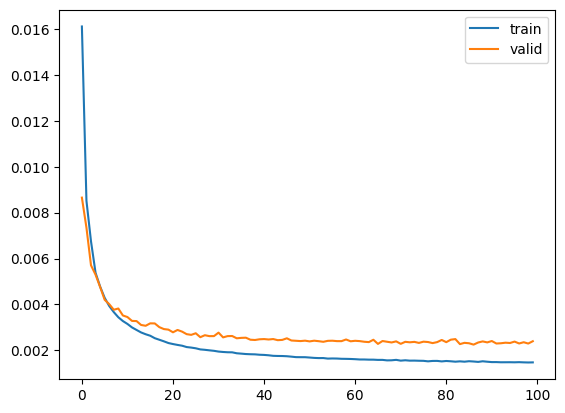

In [ ]:
plt.plot(train_history,label='train')
plt.plot(valid_history,label='valid')
plt.legend()
plt.show()

In [ ]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
#test = []
with torch.no_grad():
    for idx, batch in enumerate(test_rolling_madrid):
        batch = torch.Tensor(batch).to(device)
        nan = torch.isnan(batch)
        batch[nan]=0.0
        rec = model(batch[None,:])[0].cpu().numpy()
        nan = nan.cpu().numpy()
        test_rolling_madrid[idx][nan]=rec[nan]

In [ ]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_linear = scaler.inverse_transform(test_madrid_normal)

In [ ]:
recovery_nn['linear'] = test_linear

19223.47670004051


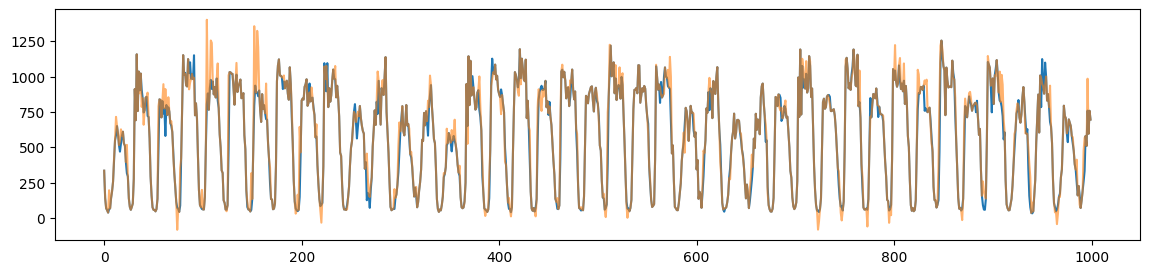

In [ ]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_linear[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_linear[index].reshape(1,-1)))

##### 7.2.3 Реккурентная модель востановлениях данных


In [ ]:
class EncoderGRU(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.size_subsequent=size_subsequent
        self.dim = dim
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size=dim,
                          hidden_size=self.hidden_size)

        self.latten = nn.Linear(hidden_size*size_subsequent,latten_size)
        self.leaky = nn.LeakyReLU()
        self.fl = nn.Flatten()
    def forward(self, x):
        x, _ = self.gru(x)
        x = self.leaky(x)
        #print(x.shape)
        x = self.fl(x)
        x = self.latten(x)
        return self.leaky(x)


In [ ]:
class DecoderGRU(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.size_subsequent=size_subsequent
        self.dim = dim
        self.hidden_size = hidden_size
        self.latten_size=latten_size
        self.gru = nn.GRU(input_size=self.hidden_size,
                          hidden_size=dim)
        self.latten = nn.Linear(latten_size,hidden_size*size_subsequent)
        self.leaky = nn.LeakyReLU()

    def forward(self, x):
        x = self.latten(x)
        x = x.view(-1, self.size_subsequent, self.latten_size)
        x = self.leaky(x)
        x, _ = self.gru(x)
        return self.leaky(x)


In [ ]:
class TimeAE(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.encoder = EncoderGRU(size_subsequent=size_subsequent,
                                 dim=dim,
                                 latten_size=latten_size,
                                 hidden_size=hidden_size)
        self.decoder = DecoderGRU(size_subsequent=size_subsequent,
                                 dim=dim,
                                 latten_size=latten_size,
                                 hidden_size=hidden_size)
    def forward(self, x):
        x=self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
model = TimeAE(size_subsequent=train.shape[1],dim=train.shape[2])
optimizer = torch.optim.Adam(model.parameters(),lr=1.0e-3)
loss_func = nn.MSELoss()
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
batch_size = 64
percent = 0.25

train_loader = DataLoader(train,batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(test,batch_size=batch_size,shuffle=True)


epochs = 100

In [ ]:
model

TimeAE(
  (encoder): EncoderGRU(
    (gru): GRU(10, 100)
    (latten): Linear(in_features=10000, out_features=100, bias=True)
    (leaky): LeakyReLU(negative_slope=0.01)
    (fl): Flatten(start_dim=1, end_dim=-1)
  )
  (decoder): DecoderGRU(
    (gru): GRU(100, 10)
    (latten): Linear(in_features=100, out_features=10000, bias=True)
    (leaky): LeakyReLU(negative_slope=0.01)
  )
)

In [ ]:
model=model.to(device)
train_history = []
valid_history = []
start = time.time()
for epoch in np.arange(epochs):
    train_loss =0
    valid_loss =0

    for i, x in enumerate(train_loader):
        if x.shape[0]==batch_size:
            optimizer.zero_grad()
            x = x.to(device).to(torch.float32)
            test_index = np.isnan(x.cpu().numpy())
            X = x.clone()
            X, nan = add_nan(X,percent)
            #

            recovery = model(X)
            loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
            train_loss += loss.detach().cpu().item()
            loss.backward()
            optimizer.step()
    train_loss/=(i+1)
    with torch.no_grad():
        for i, x in enumerate(valid_loader):
            if x.shape[0]==batch_size:
                x = x.to(device).to(torch.float32)
                test_index = np.isnan(x.cpu().numpy())
                X = x.clone()
                X, nan = add_nan(X,percent)
                #

                recovery = model(X)
                loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
                valid_loss += loss.detach().cpu().item()
    valid_loss/=(i+1)
    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'epoch:{epoch+1} train:{train_loss}, valid:{valid_loss}')
end = time.time()

epoch:1 train:0.005667857565271215, valid:0.0048371934866200585
epoch:2 train:0.00420799586293912, valid:0.004097167624507186
epoch:3 train:0.0035405969621891947, valid:0.003608167110112055
epoch:4 train:0.003133067681893021, valid:0.0032865865636154895
epoch:5 train:0.002844720459775107, valid:0.0030663977774192195
epoch:6 train:0.0026280734780819025, valid:0.0028908427194656097
epoch:7 train:0.0024395643169652687, valid:0.002762273224720428
epoch:8 train:0.002310831576114756, valid:0.002648445248762651
epoch:9 train:0.0021598582576168165, valid:0.002507162047550082
epoch:10 train:0.0020520448929119955, valid:0.002424571598165257
epoch:11 train:0.0019568192395221055, valid:0.002385350184284093
epoch:12 train:0.0018743742489295216, valid:0.0022636219126338413
epoch:13 train:0.0018025992480124493, valid:0.0022381309459577926
epoch:14 train:0.001751357673888605, valid:0.002197221281591716
epoch:15 train:0.0016929136809511146, valid:0.002117336496653021
epoch:16 train:0.001646642735534815

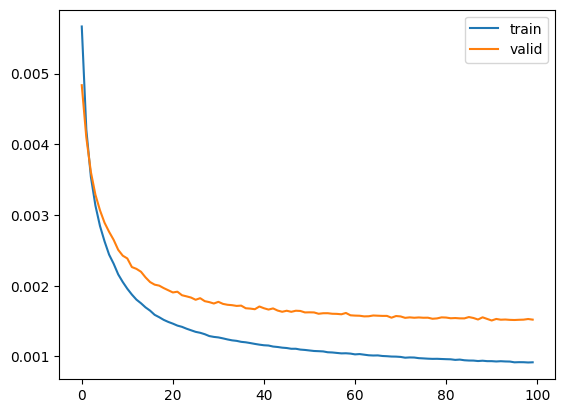

In [ ]:
plt.plot(train_history,label='train')
plt.plot(valid_history,label='valid')
plt.legend()
plt.show()

In [ ]:
times_model['ae']=end-start

In [ ]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
#test = []
with torch.no_grad():
    for idx, batch in enumerate(test_rolling_madrid):
        batch = torch.Tensor(batch).to(device)
        nan = torch.isnan(batch)
        #

        rec = model(batch[None,:])[0].cpu().numpy()
        nan = nan.cpu().numpy()
        test_rolling_madrid[idx][nan]=rec[nan]

In [ ]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_ae = scaler.inverse_transform(test_madrid_normal)

In [ ]:
recovery_nn['test_ae'] = test_ae

7815.347353696892


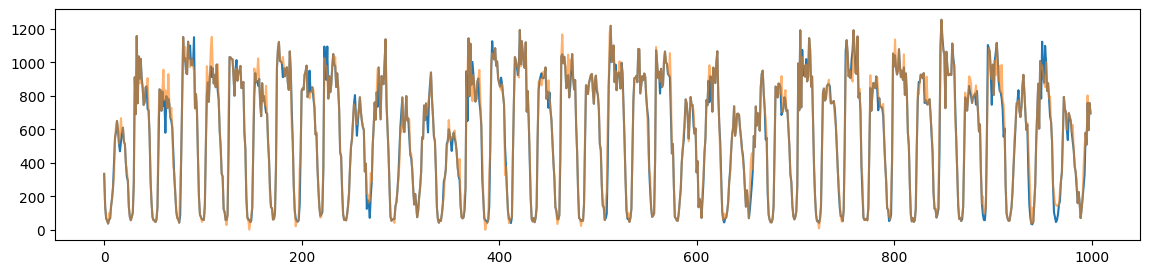

In [ ]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_ae[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_ae[index].reshape(1,-1)))

##### 7.2.4 Сложные модели нейросетевого восстановления данных


Вам необходимо выбрать одну модель из 3 группы таблицы 7.2 и используя документацию произвести восстановления того же ряда. Произведите замер времени.

In [ ]:
!pip install pypots==0.0.9

In [ ]:
from pypots.imputation import SAITS


In [ ]:
model= SAITS(n_features=madrid.shape[1],
             n_steps=100,
             device=device,
             d_k=64,
             d_v=64,
             d_model=128,
             d_inner=128,
             n_head=4,
             n_layers=2,
             dropout=0.05,
             epochs=100)

Model initialized successfully. Number of the trainable parameters: 667608


In [ ]:
start = time.time()
model.fit(train,test)
end = time.time()
times_model['saits']=end-start

epoch 0: training loss 0.1332, validating loss 0.0487
epoch 1: training loss 0.0748, validating loss 0.0418


In [ ]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
test_rolling_madrid = model.impute(test_rolling_madrid)


In [ ]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_saits = scaler.inverse_transform(test_madrid_normal)

In [ ]:
recovery_nn['saits'] = test_saits

4653.035675034267


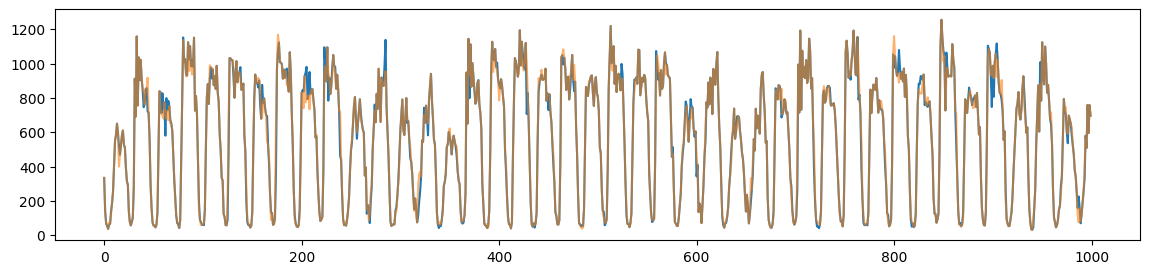

In [ ]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_saits[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_saits[index].reshape(1,-1)))

##### 7.2.5 Сравнения результатов.
Также, как и в пункте 7.1.5 постройте графики сравнения моделей. Дополнительно постройте графики сравнения времени. Сделайте выводы

#### **7.3 Прогноз временного ряда**

##### *Краткое описание*

Используя модель и [ARIMA](реализация) произвидите прогноз ряда на следующие колличество точек: 1, 5, 10.
Сравните результаты. Постройте графики прогноза и точности прогноза.